# Loan Default Prediction using Machine Learning

This project predicts whether a borrower will default on a loan using machine learning techniques. 
The dataset contains financial and demographic information about loan applicants.

Objectives:
• Analyze loan applicant data
• Build machine learning models
• Evaluate model performance
• Identify important features influencing loan default

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("../data/Raw/loan.csv")


C:\Users\Rudra\AppData\Local\Temp\ipykernel_18660\1818405376.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Raw/loan.csv")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


In [4]:
df.isnull().sum()

id                                0
member_id                         0
loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
                              ...  
tax_liens                        39
tot_hi_cred_lim               39717
total_bal_ex_mort             39717
total_bc_limit                39717
total_il_high_credit_limit    39717
Length: 111, dtype: int64

In [5]:
# Clean raw column first
df['earliest_cr_line'] = df['earliest_cr_line'].astype(str).str.strip()

# Replace bad values
df['earliest_cr_line'] = df['earliest_cr_line'].replace(
    ['nan', 'None', ''], pd.NA
)

# Convert to datetime (CRITICAL FIX)
df['earliest_cr_line'] = pd.to_datetime(
    df['earliest_cr_line'],
    format='%b-%y',
    errors='coerce'
)

In [6]:
from datetime import datetime

current_year = datetime.now().year

df['credit_history_years'] = (
    (pd.Timestamp.now() - df['earliest_cr_line']).dt.days / 365
)

# Fix negative values (future dates)
df.loc[df['credit_history_years'] < 0, 'credit_history_years'] = \
    df['credit_history_years'].median()

In [7]:
print(df['earliest_cr_line'].head())
print("NaT count:", df['earliest_cr_line'].isna().sum())

0   1985-01-01
1   1999-04-01
2   2001-11-01
3   1996-02-01
4   1996-01-01
Name: earliest_cr_line, dtype: datetime64[ns]
NaT count: 0


In [8]:


df['int_rate'] = pd.to_numeric(df['int_rate'].astype(str).str.rstrip('%'), errors='coerce') / 100
df['revol_util'] = pd.to_numeric(df['revol_util'].astype(str).str.rstrip('%'), errors='coerce') / 100

In [9]:

def map_status(x):
    if x in ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']:
        return 1
    else:
        return 0



df['loan_status'] = df['loan_status'].apply(map_status)

In [10]:
drop_cols = [
'id','member_id','url','desc','title','zip_code',
'issue_d','last_pymnt_d','next_pymnt_d','last_credit_pull_d'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [11]:
leakage_cols = [
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv'
]

df = df.drop(columns=leakage_cols, errors='ignore')

In [12]:
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().all():
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().all():
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

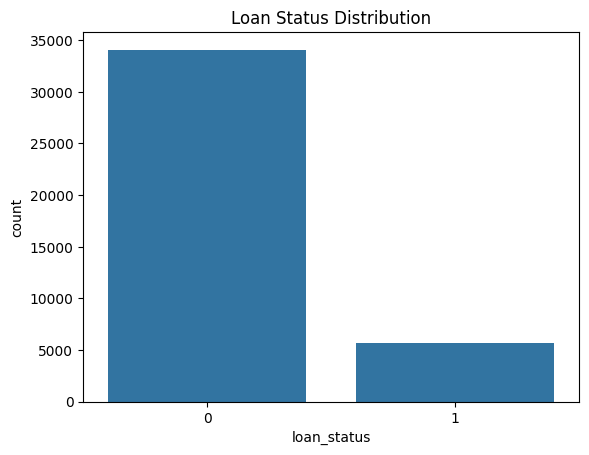

In [14]:
sns.countplot(x='loan_status',data=df)
plt.title("Loan Status Distribution")
plt.show()

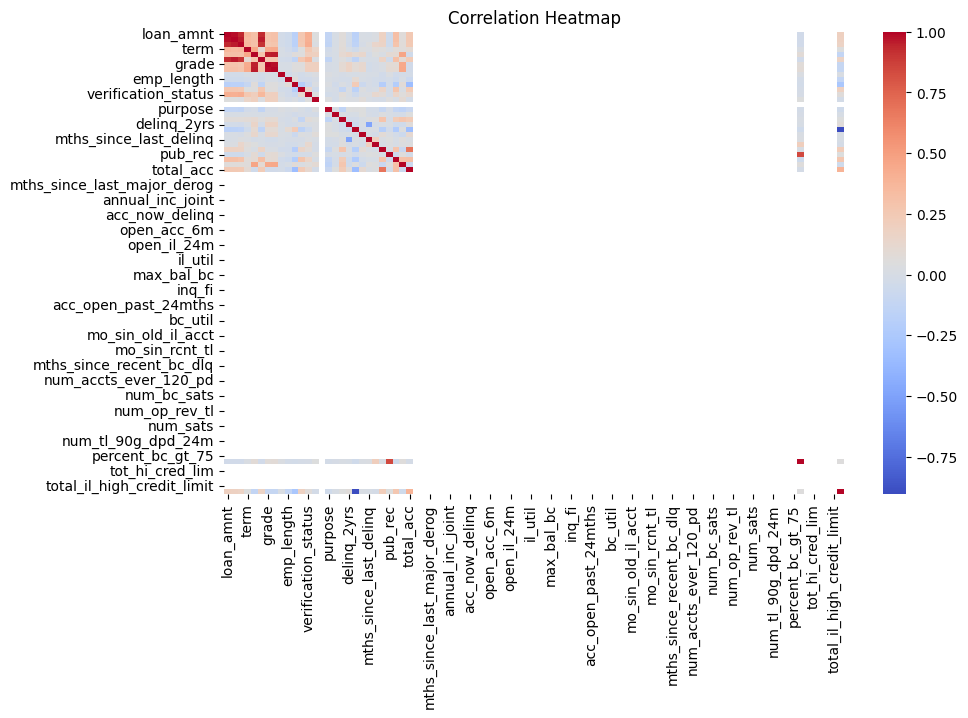

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
features = [
    "loan_amnt", "int_rate", "annual_inc", "dti",
    "revol_util", "revol_bal", "installment",
    "total_acc", "open_acc", "credit_history_years"
]

X = df[features]
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Fill missing values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)


In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [19]:
RandomForestClassifier(class_weight='balanced')


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
DecisionTreeClassifier(class_weight='balanced')

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [21]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

In [22]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

In [23]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.625504,0.213089,0.610667,0.315935
3,KNN,0.626133,0.180243,0.462222,0.259352
1,Decision Tree,0.731495,0.186957,0.267556,0.220110
2,Random Forest,0.816088,0.261364,0.163556,0.201203


In [24]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [25]:
features = [
    "loan_amnt", "int_rate", "annual_inc", "dti",
    "revol_util", "revol_bal", "installment",
    "total_acc", "open_acc", "credit_history_years"
]

X = df[features]

In [26]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
result_lr = []
result_lr.append({
        "Model": LogisticRegression.__name__,
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1 Score": f1_score(y_test, y_pred_lr)
    })
results_lr = pd.DataFrame(result_lr)
results_lr


,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.625504,0.213089,0.610667,0.315935


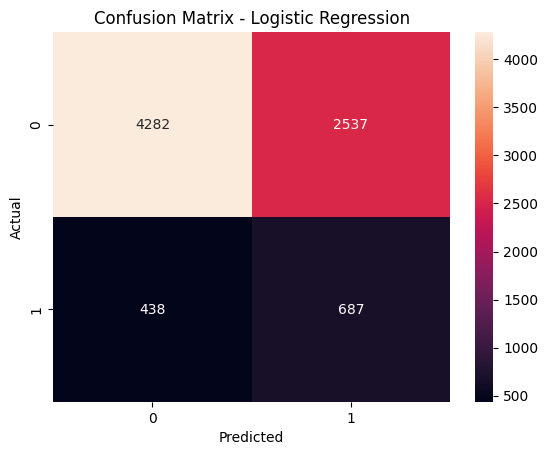

In [27]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Multiple machine learning models, including Logistic Regression, Decision Tree, K-Nearest Neighbors (KNN), and Random Forest, were evaluated for predicting loan default risk. Each model was trained and tested using the same dataset and assessed using accuracy, precision, recall, F1-score, and ROC-AUC to ensure a fair comparison.

Initially, most models achieved high accuracy, particularly Random Forest and Logistic Regression, both exceeding 85%. However, further analysis revealed that these models performed poorly in identifying defaulters due to class imbalance, as indicated by extremely low recall values.

To address this issue, class balancing techniques were applied using SMOTE. After balancing, all models were re-evaluated. Logistic Regression showed a significant improvement in recall, achieving the highest recall among all models, along with a balanced F1-score and consistent ROC-AUC performance. KNN also showed moderate improvement, while Decision Tree provided limited gains. Random Forest, despite maintaining relatively high accuracy, continued to exhibit low recall, making it less effective in identifying high-risk borrowers.

Since loan default prediction is a high-risk financial problem where failing to identify defaulters can lead to significant losses, recall was prioritized as the key evaluation metric. Based on this criterion, Logistic Regression was selected as the final model, as it demonstrated the best ability to correctly identify defaulters while maintaining reasonable overall performance.

Therefore, Logistic Regression was finalized for further deployment and integration into the application.

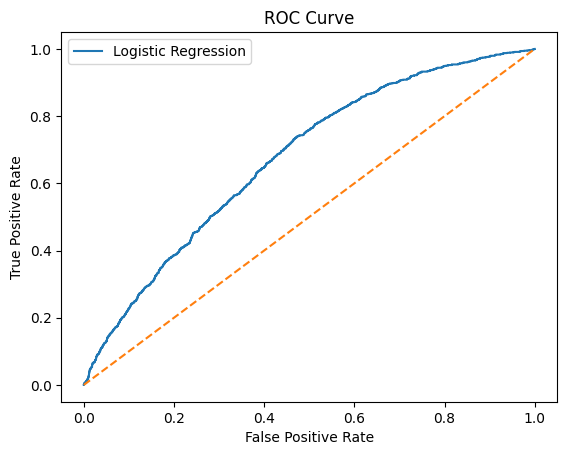

AUC Score: 0.6737346303628751


In [28]:


y_prob_lr = lr.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob_lr[:,1])

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# AUC
auc = roc_auc_score(y_test, y_prob_lr[:,1])
print("AUC Score:", auc)

In [29]:
importance = pd.Series(
    lr.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

top_features = importance.head(15)
print(top_features)

int_rate                0.586416
installment            -0.456197
loan_amnt               0.439729
annual_inc             -0.398954
total_acc              -0.064586
revol_util              0.060463
credit_history_years    0.057170
open_acc                0.053299
dti                     0.037457
revol_bal               0.016892
dtype: float64


In [30]:
from joblib import dump

dump(lr, "../models/logistic_model.joblib")
dump(scaler, "../models/scaler.joblib")
dump(X.columns.tolist(), "../models/model_features.pkl")

['../models/model_features.pkl']

In [31]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [32]:
from joblib import dump
dump(pipeline, "../models/loan_model.joblib")

['../models/loan_model.joblib']

In [33]:
print(X.describe())

          loan_amnt      int_rate    annual_inc           dti    revol_util  \
count  39717.000000  39717.000000  3.971700e+04  39717.000000  39717.000000   
mean   11219.443815      0.120212  6.896893e+04     13.315130      0.488327   
std     7456.670694      0.037248  6.379377e+04      6.678594      0.283148   
min      500.000000      0.054200  4.000000e+03      0.000000      0.000000   
25%     5500.000000      0.092500  4.040400e+04      8.170000      0.255000   
50%    10000.000000      0.118600  5.900000e+04     13.400000      0.493000   
75%    15000.000000      0.145900  8.230000e+04     18.600000      0.723000   
max    35000.000000      0.245900  6.000000e+06     29.990000      0.999000   

           revol_bal   installment     total_acc      open_acc  \
count   39717.000000  39717.000000  39717.000000  39717.000000   
mean    13382.528086    324.561922     22.088828      9.294408   
std     15885.016641    208.874874     11.401709      4.400282   
min         0.000000    

In [34]:
df['credit_history_years'].describe()

count    39717.000000
mean        29.163810
std          6.666761
min         17.446575
25%         24.619178
50%         27.958904
75%         32.375342
max         57.221918
Name: credit_history_years, dtype: float64

In [35]:

print(X.isna().sum())

loan_amnt               0
int_rate                0
annual_inc              0
dti                     0
revol_util              0
revol_bal               0
installment             0
total_acc               0
open_acc                0
credit_history_years    0
dtype: int64
